In [1]:
from source_code import *
import numpy as np

import matplotlib.pyplot as plt

plt.style.use("bmh")

In [2]:
taskc= LagrangeInterpolator(-5,5,piecewise=True, point_type='chebyshev',K =3,num_points=3)

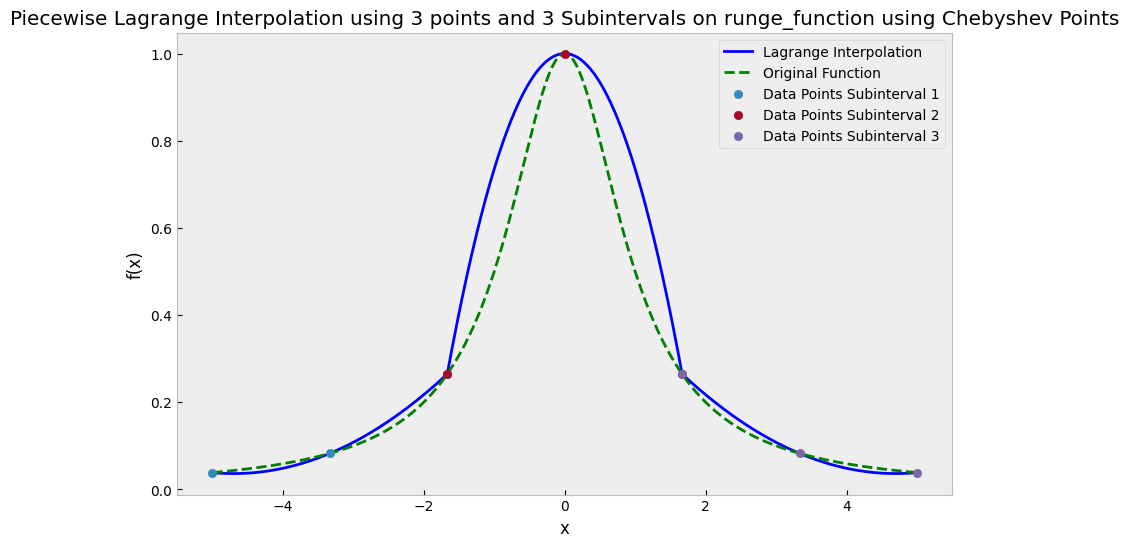

In [3]:
taskc.plot_interpolation()

In [4]:
def test_error_aprox_vary_K(function_intervals):
    """
    Approximate and plot the L2 and max errors while varying K,
    using 5 interpolation points per subinterval.
    """

    K_vals = np.arange(1, 100)
    num_points = 5

    fig, axes = plt.subplots(
        len(function_intervals),
        2,
        figsize=(14, 5 * len(function_intervals)),
        squeeze=False
    )

    for row, (func, start, end) in enumerate(function_intervals):
        x_error_eval = np.linspace(start, end, 5000)

        for col, point_type in enumerate(["equidistant", "chebyshev"]):
            errors_max = []
            errors_l2 = []

            for K in K_vals:
                interpolator = LagrangeInterpolator(
                    start,
                    end,
                    num_points=num_points,
                    function=func,
                    point_type=point_type,
                    piecewise=True,
                    K=K
                )

                exact_values = interpolator.func(x_error_eval)
                interpolated_values = interpolator.piecewise_interpolation(
                    x_error_eval
                )

                error = np.abs(exact_values - interpolated_values)

                errors_max.append(np.max(error))
                errors_l2.append(
                    np.sqrt(np.trapezoid(error**2, x_error_eval))
                )

            ax = axes[row, col]
            ax.plot(K_vals, errors_max, label="Max norm", marker="o")
            ax.plot(K_vals, errors_l2, label="L2 norm", marker="o")

            ax.set_title(
                f"{func}: [{start}, {end}] ({point_type}), "
                f"{num_points} points per subinterval"
            )
            ax.set_xlabel("Number of subintervals K")
            ax.set_ylabel("Error")
            ax.set_yscale("log")
            ax.grid(True)
            ax.legend()

    plt.tight_layout()
    plt.show()

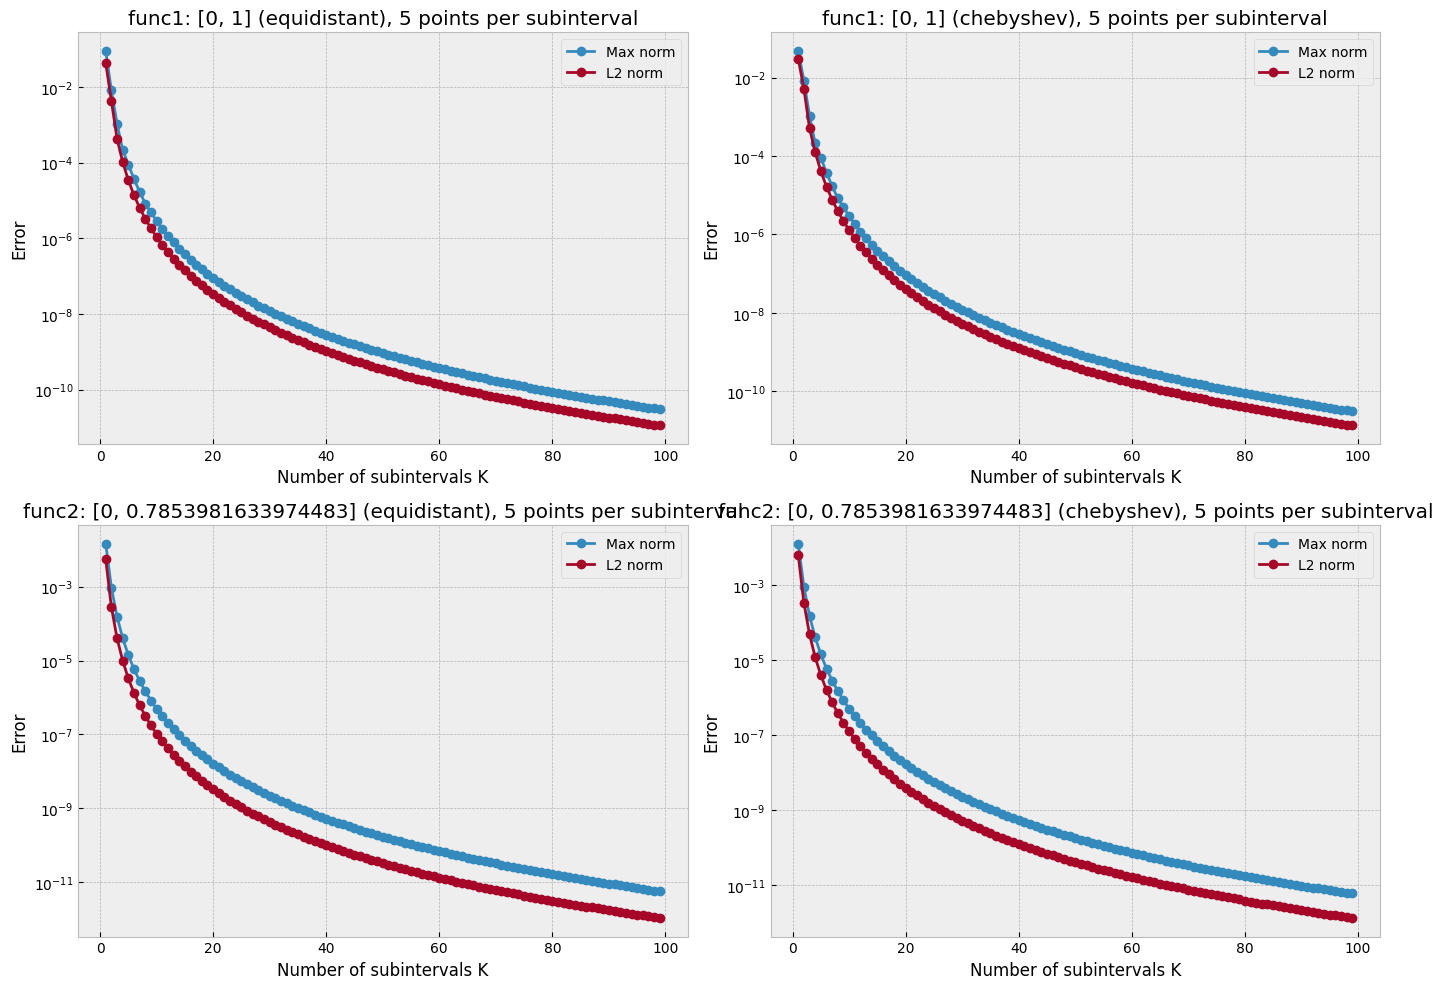

In [5]:
test_error_aprox_vary_K([
    ("func1", 0, 1),
    ("func2", 0, np.pi / 4)
])